# Disasters effects classification

In order to better understand which feats. are useful and which aren't we solve a simple ML task of predicting weather the disaster caused deaths / damages.

### imports

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
import calendar
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## Dataset preparation

### Dataset loading

In [101]:
# Define paths to the storm events CSV files
data_dir = Path('../datasets\\')
files = [
    data_dir / 'StormEvents_details-ftp_v1.0_d2016_c20250818.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2017_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2018_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2019_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2020_c20251118.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2021_c20250520.csv',
    data_dir / 'StormEvents_details-ftp_v1.0_d2022_c20250721.csv',
]

# Load datasets
print("Loading datasets...")
df_list = []
for file in files:
    # print(f"  Loading {file.name}...")
    df = pd.read_csv(file)
    # print(f"    Shape: {df.shape}")
    df_list.append(df)

# Concatenate the datasets
df = pd.concat(df_list, ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")

Loading datasets...

Combined dataset shape: (436146, 51)


In [102]:
useless_cols = [
    'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 
    'END_YEARMONTH', 'END_DAY', 'END_TIME',
    'EPISODE_ID', 'EVENT_ID',
    'STATE_FIPS',
    'SOURCE',
    'YEAR',
    'MONTH_NAME',
    'WFO',
    'CATEGORY',
    'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 
    'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME', 'CZ_TIMEZONE',
    'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE',
    
    'FLOOD_CAUSE',
    'TOR_LENGTH',
    'TOR_WIDTH',
    'BEGIN_RANGE',
    'BEGIN_AZIMUTH',
    'BEGIN_LOCATION',
    'END_RANGE',
    'END_AZIMUTH',
    'END_LOCATION',
    'END_LAT',
    'END_LON',
    'MAGNITUDE_TYPE',
    'TOR_F_SCALE',
]

df = df.drop(columns=useless_cols, inplace=False)

In [103]:
df.columns

Index(['STATE', 'EVENT_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'MAGNITUDE',
       'BEGIN_LAT', 'BEGIN_LON'],
      dtype='object')

### Aggregate cols

In [104]:
df['EVENT_TYPE'] = df['EVENT_TYPE'].replace({
    'Thunderstorm Wind': 'Wind',
    'Hail': 'Hail',
    'Marine Hail': 'Hail',
    'Flood': 'Flood',
    'Flash Flood': 'Flood',
    'Coastal Flood': 'Flood',
    'Lakeshore Flood': 'Flood',
    'Winter Weather': 'Freeze',
    'Extreme Cold/Wind Chill': 'Freeze',
    'Frost/Freeze': 'Freeze',
    'Cold/Wind Chill': 'Freeze',
    'Freezing Fog': 'Freeze',
    'Heat': 'Heat',
    'Excessive Heat': 'Heat',
    'Heavy Snow': 'Snow',
    'Blizzard': 'Snow',
    'Lake-Effect Snow': 'Snow',
    'Sleet': 'Snow',
    'Winter Storm': 'Storm',
    'Marine Thunderstorm Wind': 'Storm',
    'Tornado': 'Storm',
    'Tropical Storm': 'Storm',
    'Dust Storm': 'Storm',
    'Funnel Cloud': 'Storm',
    'Ice Storm': 'Storm',
    'Waterspout': 'Storm',
    'Marine Tropical Storm': 'Storm',
    'Hurricane (Typhoon)': 'Storm',
    'Marine Hurricane/Typhoon': 'Storm',
    'High Wind':  'Wind',
    'Strong Wind':  'Wind',
    'Marine High Wind':  'Wind',
    'Marine Strong Wind':  'Wind',
    'Dense Fog':  'Fog',
    'Marine Dense Fog':  'Fog'
})

In [105]:
def damage_to_numeric(damage_str):
    if pd.isna(damage_str):
        return 0
    multipliers = {'K': 1_000, 'M': 1_000_000, 'B': 1_000_000_000}
    if damage_str[-1] in multipliers:
        try:
            value = float(damage_str[:-1])
            return value * multipliers[damage_str[-1]]
        except ValueError:
            return 0
    try:
        return float(damage_str)
    except ValueError:
        return 0   

df['DAMAGES'] = df['DAMAGE_PROPERTY'].apply(damage_to_numeric) + df['DAMAGE_CROPS'].apply(damage_to_numeric)
df.drop(columns=['DAMAGE_PROPERTY', 'DAMAGE_CROPS'], inplace=True)

In [106]:
df['CASUALTIES'] = df['INJURIES_DIRECT'].fillna(0) + df['INJURIES_INDIRECT'].fillna(0) + df['DEATHS_DIRECT'].fillna(0) + df['DEATHS_INDIRECT'].fillna(0)
df.drop(columns=['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT'], inplace=True)

### Encode cols

In [107]:
# create HAIL_SIZE and WIND_SPEED columns from MAGNITUDE
df['HAIL_SIZE'] = df['MAGNITUDE'].where(df['EVENT_TYPE'] == 'Hail', other=0)
df['WIND_SPEED'] = df['MAGNITUDE'].where(df['EVENT_TYPE'] != 'Hail', other=0)
df['WIND_SPEED'] = df['WIND_SPEED'].fillna(0)
df.drop(columns=['MAGNITUDE'], inplace=True)

In [108]:
# categorial -> numeric
# df['STATE'] = df['STATE'].astype('category').cat.codes
df['EVENT_TYPE'] = df['EVENT_TYPE'].astype('category').cat.codes

In [109]:
# fill BEGIN_LAT and BEGIN_LON NaN values with the mean of their respective columns
df['BEGIN_LAT'] = df['BEGIN_LAT'].fillna(df['BEGIN_LAT'].mean())
df['BEGIN_LON'] = df['BEGIN_LON'].fillna(df['BEGIN_LON'].mean())

In [110]:
# encode time cols BEGIN_DATE_TIME and END_DATE_TIME
df['BEGIN_DATE_TIME'] = pd.to_datetime(df['BEGIN_DATE_TIME'])
df['END_DATE_TIME'] = pd.to_datetime(df['END_DATE_TIME'])

# # Extract hour and day of year
# for prefix in ['BEGIN', 'END']:
#     dt_col = f'{prefix}_DATE_TIME'
#     # Hour of day cyclical encoding
#     df[f'{prefix}_HOUR_sin'] = np.sin(2 * np.pi * df[dt_col].dt.hour / 24)
#     df[f'{prefix}_HOUR_cos'] = np.cos(2 * np.pi * df[dt_col].dt.hour / 24)
#     # Day of year cyclical encoding
#     df[f'{prefix}_DOY_sin'] = np.sin(2 * np.pi * df[dt_col].dt.dayofyear / 366)
#     df[f'{prefix}_DOY_cos'] = np.cos(2 * np.pi * df[dt_col].dt.dayofyear / 366)

# Optionally drop original datetime columns
# df.drop(columns=['BEGIN_DATE_TIME', 'END_DATE_TIME'], inplace=True)

C:\Users\matti\AppData\Local\Temp\ipykernel_36840\1537381508.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['BEGIN_DATE_TIME'] = pd.to_datetime(df['BEGIN_DATE_TIME'])
C:\Users\matti\AppData\Local\Temp\ipykernel_36840\1537381508.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['END_DATE_TIME'] = pd.to_datetime(df['END_DATE_TIME'])


### Normalize cols

In [111]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
STATE,436146,67,TEXAS,29023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EVENT_TYPE,436146.0,NaN,NaN,NaN,15.823217,0.0,8.0,18.0,25.0,25.0,8.001558
BEGIN_DATE_TIME,436146,NaN,NaN,NaN,2019-07-29 09:32:33.521756416,2016-01-01 00:00:00,2017-11-18 08:22:30,2019-07-12 17:40:00,2021-05-14 18:40:00,2022-12-31 23:30:00,NaN
END_DATE_TIME,436146,NaN,NaN,NaN,2019-07-31 01:55:35.637561600,2016-01-01 03:00:00,2017-11-18 17:12:00,2019-07-13 16:32:30,2021-05-17 08:00:00,2022-12-31 23:59:00,NaN
BEGIN_LAT,436146.0,NaN,NaN,NaN,37.813228,-14.3629,37.06,37.813228,39.3263,66.8385,4.073628
BEGIN_LON,436146.0,NaN,NaN,NaN,-89.95491,-171.0327,-92.49,-89.95491,-85.97,151.8484,9.249207
DAMAGES,436146.0,NaN,NaN,NaN,504931.50468,0.0,0.0,0.0,0.0,17000000000.0,44006762.868617
CASUALTIES,436146.0,NaN,NaN,NaN,0.043708,0.0,0.0,0.0,0.0,500.0,1.481073
HAIL_SIZE,436146.0,NaN,NaN,NaN,0.164376,0.0,0.0,0.0,0.0,6.42,0.458119
WIND_SPEED,436146.0,NaN,NaN,NaN,20.145729,0.0,0.0,0.0,50.0,173.0,25.756179


In [112]:
# # EVENT_TYPE one-hot encoding
# enc = OneHotEncoder(sparse_output=False)
# event_type_encoded = enc.fit_transform(df[['EVENT_TYPE']])
# event_type_df = pd.DataFrame(event_type_encoded, columns=[f"EVENT_TYPE_{cat}" for cat in enc.categories_[0]], index=df.index)

# df = pd.concat([df.drop(columns=['EVENT_TYPE']), event_type_df], axis=1)

In [113]:
# # normalize HAIL_SIZE and WIND_SPEED
# scaler = MinMaxScaler()
# df[['HAIL_SIZE', 'WIND_SPEED']] = scaler.fit_transform(df[['HAIL_SIZE', 'WIND_SPEED']])

# # normalize BEGIN_LAT and BEGIN_LON
# scaler = MinMaxScaler()
# df[['BEGIN_LAT', 'BEGIN_LON']] = scaler.fit_transform(df[['BEGIN_LAT', 'BEGIN_LON']])

In [114]:
# # normalize DURATION_HOURS
# scaler = MinMaxScaler()
# df[['DURATION_HOURS']] = scaler.fit_transform(df[['DURATION_HOURS']])

# # normalize DAMAGES and CASUALTIES
# scaler = MinMaxScaler()
# df[['DAMAGES', 'CASUALTIES']] = scaler.fit_transform(df[['DAMAGES', 'CASUALTIES']])

In [115]:
# df['STATE'] = df['STATE'].astype('category').cat.codes
df['BEGIN_DATE_TIME'] = df['BEGIN_DATE_TIME'].astype('int64')
df['END_DATE_TIME'] = df['END_DATE_TIME'].astype('int64')
df['CASUALTIES'] = df['CASUALTIES'] > 0
df['DAMAGES'] = df['DAMAGES'] >= 1000
df['CASUALTIES'] = df['CASUALTIES'].astype(int)
df['DAMAGES'] = df['DAMAGES'].astype(int)

scaler = StandardScaler()
df[['EVENT_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'BEGIN_LAT', 'BEGIN_LON', 'HAIL_SIZE', 'WIND_SPEED']] = scaler.fit_transform(df[['EVENT_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'BEGIN_LAT', 'BEGIN_LON', 'HAIL_SIZE', 'WIND_SPEED']])


## Training and Inference

In [116]:
df.head()

,STATE,EVENT_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,BEGIN_LAT,BEGIN_LON,DAMAGES,CASUALTIES,HAIL_SIZE,WIND_SPEED
0,SOUTH CAROLINA,-0.602785,-1.508844,-1.509876,-0.705325,0.964939,1,0,-0.358807,-0.782172
1,SOUTH CAROLINA,1.146876,-1.508834,-1.509867,-0.688141,0.975751,0,0,-0.358807,1.159112
2,NORTH CAROLINA,1.146876,-1.507737,-1.508771,-0.533488,0.844929,0,0,-0.358807,1.159112
3,TENNESSEE,1.146876,-1.518332,-1.519357,-0.531033,0.624369,0,0,-0.358807,1.159112
4,TENNESSEE,1.146876,-1.518318,-1.519343,-0.477027,0.668697,0,0,-0.358807,1.547369


### Single model

In [ ]:
# set y as DAMAGES and CASUALTIES
y = df[['DAMAGES']].to_numpy().ravel()
X = df.drop(columns=['DAMAGES', 'CASUALTIES'])
print(X.shape, y.shape)

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(436146, 4) (436146,)


In [85]:
# make a MLP regressor model to predict DAMAGES and CASUALTIES
model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu', solver='adam', max_iter=100, random_state=42)
model.fit(X_train, y_train)

model.score(X_test, y_test)

c:\Users\matti\anaconda3\envs\ai\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


0.875558867362146

#### Plots

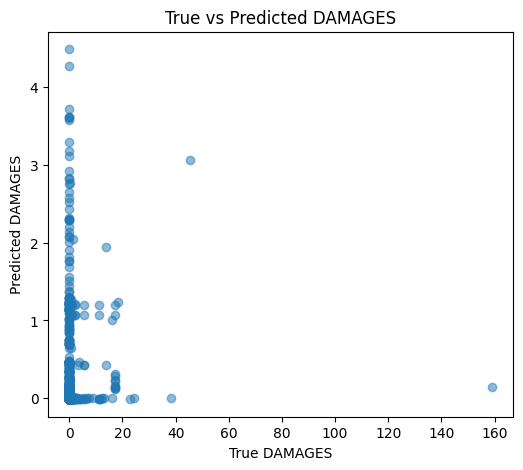

In [ ]:
# plot the true vs predicted values for DAMAGES and CASUALTIES
y_pred = model.predict(X_test)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test['DAMAGES'], y_pred[:, 0], alpha=0.5)
plt.xlabel('True DAMAGES')
plt.ylabel('Predicted DAMAGES')
plt.title('True vs Predicted DAMAGES')
plt.subplot(1, 2, 2)
plt.scatter(y_test['CASUALTIES'], y_pred[:, 1], alpha=0.5)
plt.xlabel('True CASUALTIES')
plt.ylabel('Predicted CASUALTIES')
plt.title('True vs Predicted CASUALTIES')
plt.tight_layout()
plt.show()


### One model per state

In [159]:
dfs = df[df['STATE'] == 'CALIFORNIA']
dfs.head()

,STATE,EVENT_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,BEGIN_LAT,BEGIN_LON,DAMAGES,CASUALTIES,HAIL_SIZE,WIND_SPEED
278,CALIFORNIA,-1.227664,-1.770601,-1.771257,-8.603957e-01,-3.177680e+00,0,0,-0.358807,-0.782172
279,CALIFORNIA,-1.227664,-1.770413,-1.771143,-8.986172e-01,-3.018196e+00,0,0,-0.358807,-0.782172
280,CALIFORNIA,-1.227664,-1.769109,-1.769812,-8.464524e-01,-3.091565e+00,0,0,-0.358807,-0.782172
366,CALIFORNIA,0.397021,-1.770555,-1.769330,-1.744253e-15,-3.072884e-15,0,0,-0.358807,-0.782172
368,CALIFORNIA,1.146876,-1.769141,-1.769953,-8.385969e-01,-3.131785e+00,0,0,-0.358807,1.236764


In [160]:
y_dmg = dfs[['DAMAGES']].to_numpy().ravel()
y_cas = dfs[['CASUALTIES']].to_numpy().ravel()
X = dfs.drop(columns=['DAMAGES', 'CASUALTIES', 'STATE'])

print(X.shape, y_dmg.shape, y_cas.shape)

# split into train and test sets
X_train, X_test, y_dmg_train, y_dmg_test = train_test_split(X, y_dmg, test_size=0.2, random_state=42, shuffle=True)
X_train, X_test, y_cas_train, y_cas_test = train_test_split(X, y_cas, test_size=0.2, random_state=42, shuffle=True)

(15126, 7) (15126,) (15126,)


In [161]:
model_dmg = MLPClassifier(hidden_layer_sizes=(128, 128, 64), activation='relu', solver='adam', max_iter=500, random_state=42)
model_dmg.fit(X_train, y_dmg_train)

model_cas = MLPClassifier(hidden_layer_sizes=(128, 128, 64), activation='relu', solver='adam', max_iter=500, random_state=42)
model_cas.fit(X_train, y_cas_train)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


DAMAGES Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2732
           1       0.68      0.52      0.59       294

    accuracy                           0.93      3026
   macro avg       0.82      0.75      0.77      3026
weighted avg       0.92      0.93      0.93      3026

CASUALTIES Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      2941
           1       0.40      0.05      0.08        85

    accuracy                           0.97      3026
   macro avg       0.69      0.52      0.53      3026
weighted avg       0.96      0.97      0.96      3026



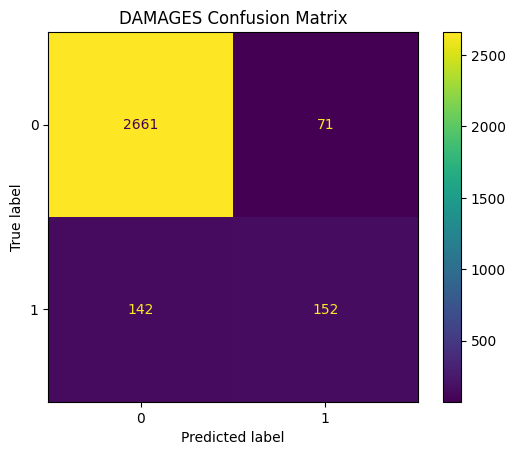

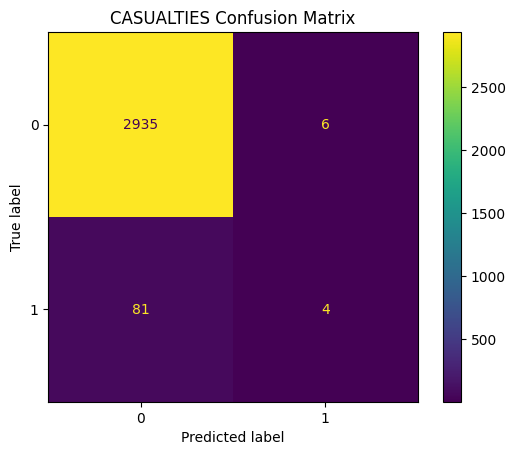

In [162]:
y_dmg_pred = model_dmg.predict(X_test)
y_cas_pred = model_cas.predict(X_test)

# print classification reports
print("DAMAGES Classification Report:")
print(classification_report(y_dmg_test, y_dmg_pred, zero_division=0))
print("CASUALTIES Classification Report:")
print(classification_report(y_cas_test, y_cas_pred, zero_division=0))

# plot confusion matrices
ConfusionMatrixDisplay.from_predictions(y_dmg_test, y_dmg_pred)
plt.title("DAMAGES Confusion Matrix")
plt.show()
ConfusionMatrixDisplay.from_predictions(y_cas_test, y_cas_pred)
plt.title("CASUALTIES Confusion Matrix")
plt.show()